In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_geometric
from torch_geometric import utils
from scipy.sparse import coo_matrix
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [2]:
ec_hic = np.load('data/GBM39ec_5k_collapsed_matrix.npy')
ec_hic.shape

(251, 251)

In [3]:
hsr_hic = np.load('data/GBM39HSR_5k_collapsed_matrix.npy')
hsr_hic.shape

(251, 251)

In [4]:
hsr_hic

array([[ 907.47367526, 1046.62437477,  413.04476421, ...,  413.75284469,
         601.48550611,  989.24916505],
       [1046.62437477,  673.99985781,  877.44608729, ...,  249.40838605,
         337.15415794,  432.91358466],
       [ 413.04476421,  877.44608729,  768.76116446, ...,  170.72095892,
         180.62959193,  268.36353898],
       ...,
       [ 413.75284469,  249.40838605,  170.72095892, ...,  996.95587715,
        1170.41401995,  715.07709293],
       [ 601.48550611,  337.15415794,  180.62959193, ..., 1170.41401995,
         997.77353735, 1424.54176471],
       [ 989.24916505,  432.91358466,  268.36353898, ...,  715.07709293,
        1424.54176471, 1053.2377301 ]])

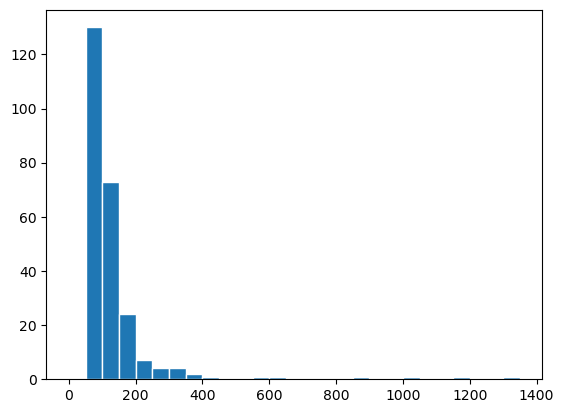

In [5]:
plt.hist(ec_hic[0], bins = np.arange(0, np.max(ec_hic[0]) + 50, 50), ec='w')
plt.show()

In [6]:
hsr_df = pd.read_csv('data/HSR_features.csv')
hsr_df.head()

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
0,NC_000001.11,0,5000,0,0,5000,0.0000,0,0
1,NC_000001.11,5000,10000,0,0,5000,0.0000,0,0
2,NC_000001.11,10000,15000,588,1083,5000,0.2166,0,0
3,NC_000001.11,15000,20000,1788,4986,5000,0.9972,1,67
4,NC_000001.11,20000,25000,2056,5000,5000,1.0000,0,0


In [7]:
hic_hsr = hsr_df[(hsr_df['start'] >= 54765000) & (hsr_df['end'] <= 56050000)]
hic_hsr

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
10953,NC_000001.11,54765000,54770000,2,3468,5000,0.6936,0,0
10954,NC_000001.11,54770000,54775000,5,5000,5000,1.0000,0,0
10955,NC_000001.11,54775000,54780000,2,5000,5000,1.0000,1,21611
10956,NC_000001.11,54780000,54785000,3,5000,5000,1.0000,0,0
10957,NC_000001.11,54785000,54790000,2,5000,5000,1.0000,0,0
...,...,...,...,...,...,...,...,...,...
618780,NC_000024.10,56025000,56030000,0,0,5000,0.0000,0,0
618781,NC_000024.10,56030000,56035000,0,0,5000,0.0000,0,0
618782,NC_000024.10,56035000,56040000,0,0,5000,0.0000,0,0
618783,NC_000024.10,56040000,56045000,0,0,5000,0.0000,0,0


In [8]:
hic_hsr.groupby('chromosome')['start'].count()

chromosome
NC_000001.11    257
NC_000002.12    257
NC_000003.12    257
NC_000004.12    257
NC_000005.10    257
NC_000006.12    257
NC_000007.14    257
NC_000008.11    257
NC_000009.12    257
NC_000010.11    257
NC_000011.10    257
NC_000012.12    257
NC_000013.11    257
NC_000014.9     257
NC_000015.10    257
NC_000016.10    257
NC_000017.11    257
NC_000018.10    257
NC_000019.10    257
NC_000020.11    257
NC_000023.11    257
NC_000024.10    257
Name: start, dtype: int64

In [9]:
hic_hsr_chr7 = hic_hsr[hic_hsr['chromosome'] == 'NC_000007.14']
hic_hsr_chr7.start.nunique()

257

In [10]:
hic_hsr_chr7[(hic_hsr_chr7['start'] >= 55125000) & (hic_hsr_chr7['start'] <= 55150000)]

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
257741,NC_000007.14,55125000,55130000,2282,5000,5000,1.0,0,0
257742,NC_000007.14,55130000,55135000,2013,5000,5000,1.0,0,0
257743,NC_000007.14,55135000,55140000,2001,5000,5000,1.0,0,0
257744,NC_000007.14,55140000,55145000,2758,5000,5000,1.0,0,0
257745,NC_000007.14,55145000,55150000,2267,5000,5000,1.0,0,0
257746,NC_000007.14,55150000,55155000,3106,5000,5000,1.0,0,0


In [11]:
hic_hsr_chr7 = hic_hsr_chr7[(hic_hsr_chr7['start'] < 55125000) | (hic_hsr_chr7['start'] > 55150000)]
hic_hsr_chr7.shape

(251, 9)

In [12]:
hic_hsr_chr7

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
257669,NC_000007.14,54765000,54770000,160,3880,5000,0.7760,0,0
257670,NC_000007.14,54770000,54775000,181,3463,5000,0.6926,0,0
257671,NC_000007.14,54775000,54780000,158,3270,5000,0.6540,0,0
257672,NC_000007.14,54780000,54785000,171,3304,5000,0.6608,0,0
257673,NC_000007.14,54785000,54790000,272,5000,5000,1.0000,0,0
...,...,...,...,...,...,...,...,...,...
257921,NC_000007.14,56025000,56030000,1951,5000,5000,1.0000,0,0
257922,NC_000007.14,56030000,56035000,6360,5000,5000,1.0000,0,0
257923,NC_000007.14,56035000,56040000,157,5000,5000,1.0000,0,0
257924,NC_000007.14,56040000,56045000,208,5000,5000,1.0000,0,0


In [13]:
ec_df = pd.read_csv('data/ecDNA_features.csv', index_col=0)
hic_ec = ec_df[(ec_df['start'] >= 54765000) & (ec_df['end'] <= 56050000)]
hic_ec_chr7 = hic_ec[hic_ec['chromosome'] == 'NC_000007.14']
hic_ec_chr7 = hic_ec_chr7[(hic_ec_chr7['start'] < 55125000) | (hic_ec_chr7['start'] > 55150000)]

hic_ec_chr7.head()

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
257669,NC_000007.14,54765000,54770000,7,319,5000,0.0638,0,0
257670,NC_000007.14,54770000,54775000,4,201,5000,0.0402,0,0
257671,NC_000007.14,54775000,54780000,20,555,5000,0.1110,0,0
257672,NC_000007.14,54780000,54785000,20,853,5000,0.1706,0,0
257673,NC_000007.14,54785000,54790000,7,353,5000,0.0706,0,0


In [14]:
to_filter = 90
thres = np.percentile(hsr_hic, to_filter)
vis_hsr = hsr_hic.copy()
vis_hsr[vis_hsr < thres] = 0
np.fill_diagonal(vis_hsr, 0)

G = nx.from_numpy_array(vis_hsr)

edge_weights = nx.get_edge_attributes(G, "weight")
tot_genes = hic_hsr_chr7.total_genes.to_numpy()
num_reads = np.log(hic_hsr_chr7.read_count.to_numpy() + 0.0000000001)

max_weight = max(edge_weights.values())
min_weight = min(edge_weights.values())
normalized_weights = {
    edge: (weight - min_weight) * 30 / (max_weight - min_weight)
    for edge, weight in edge_weights.items()
}

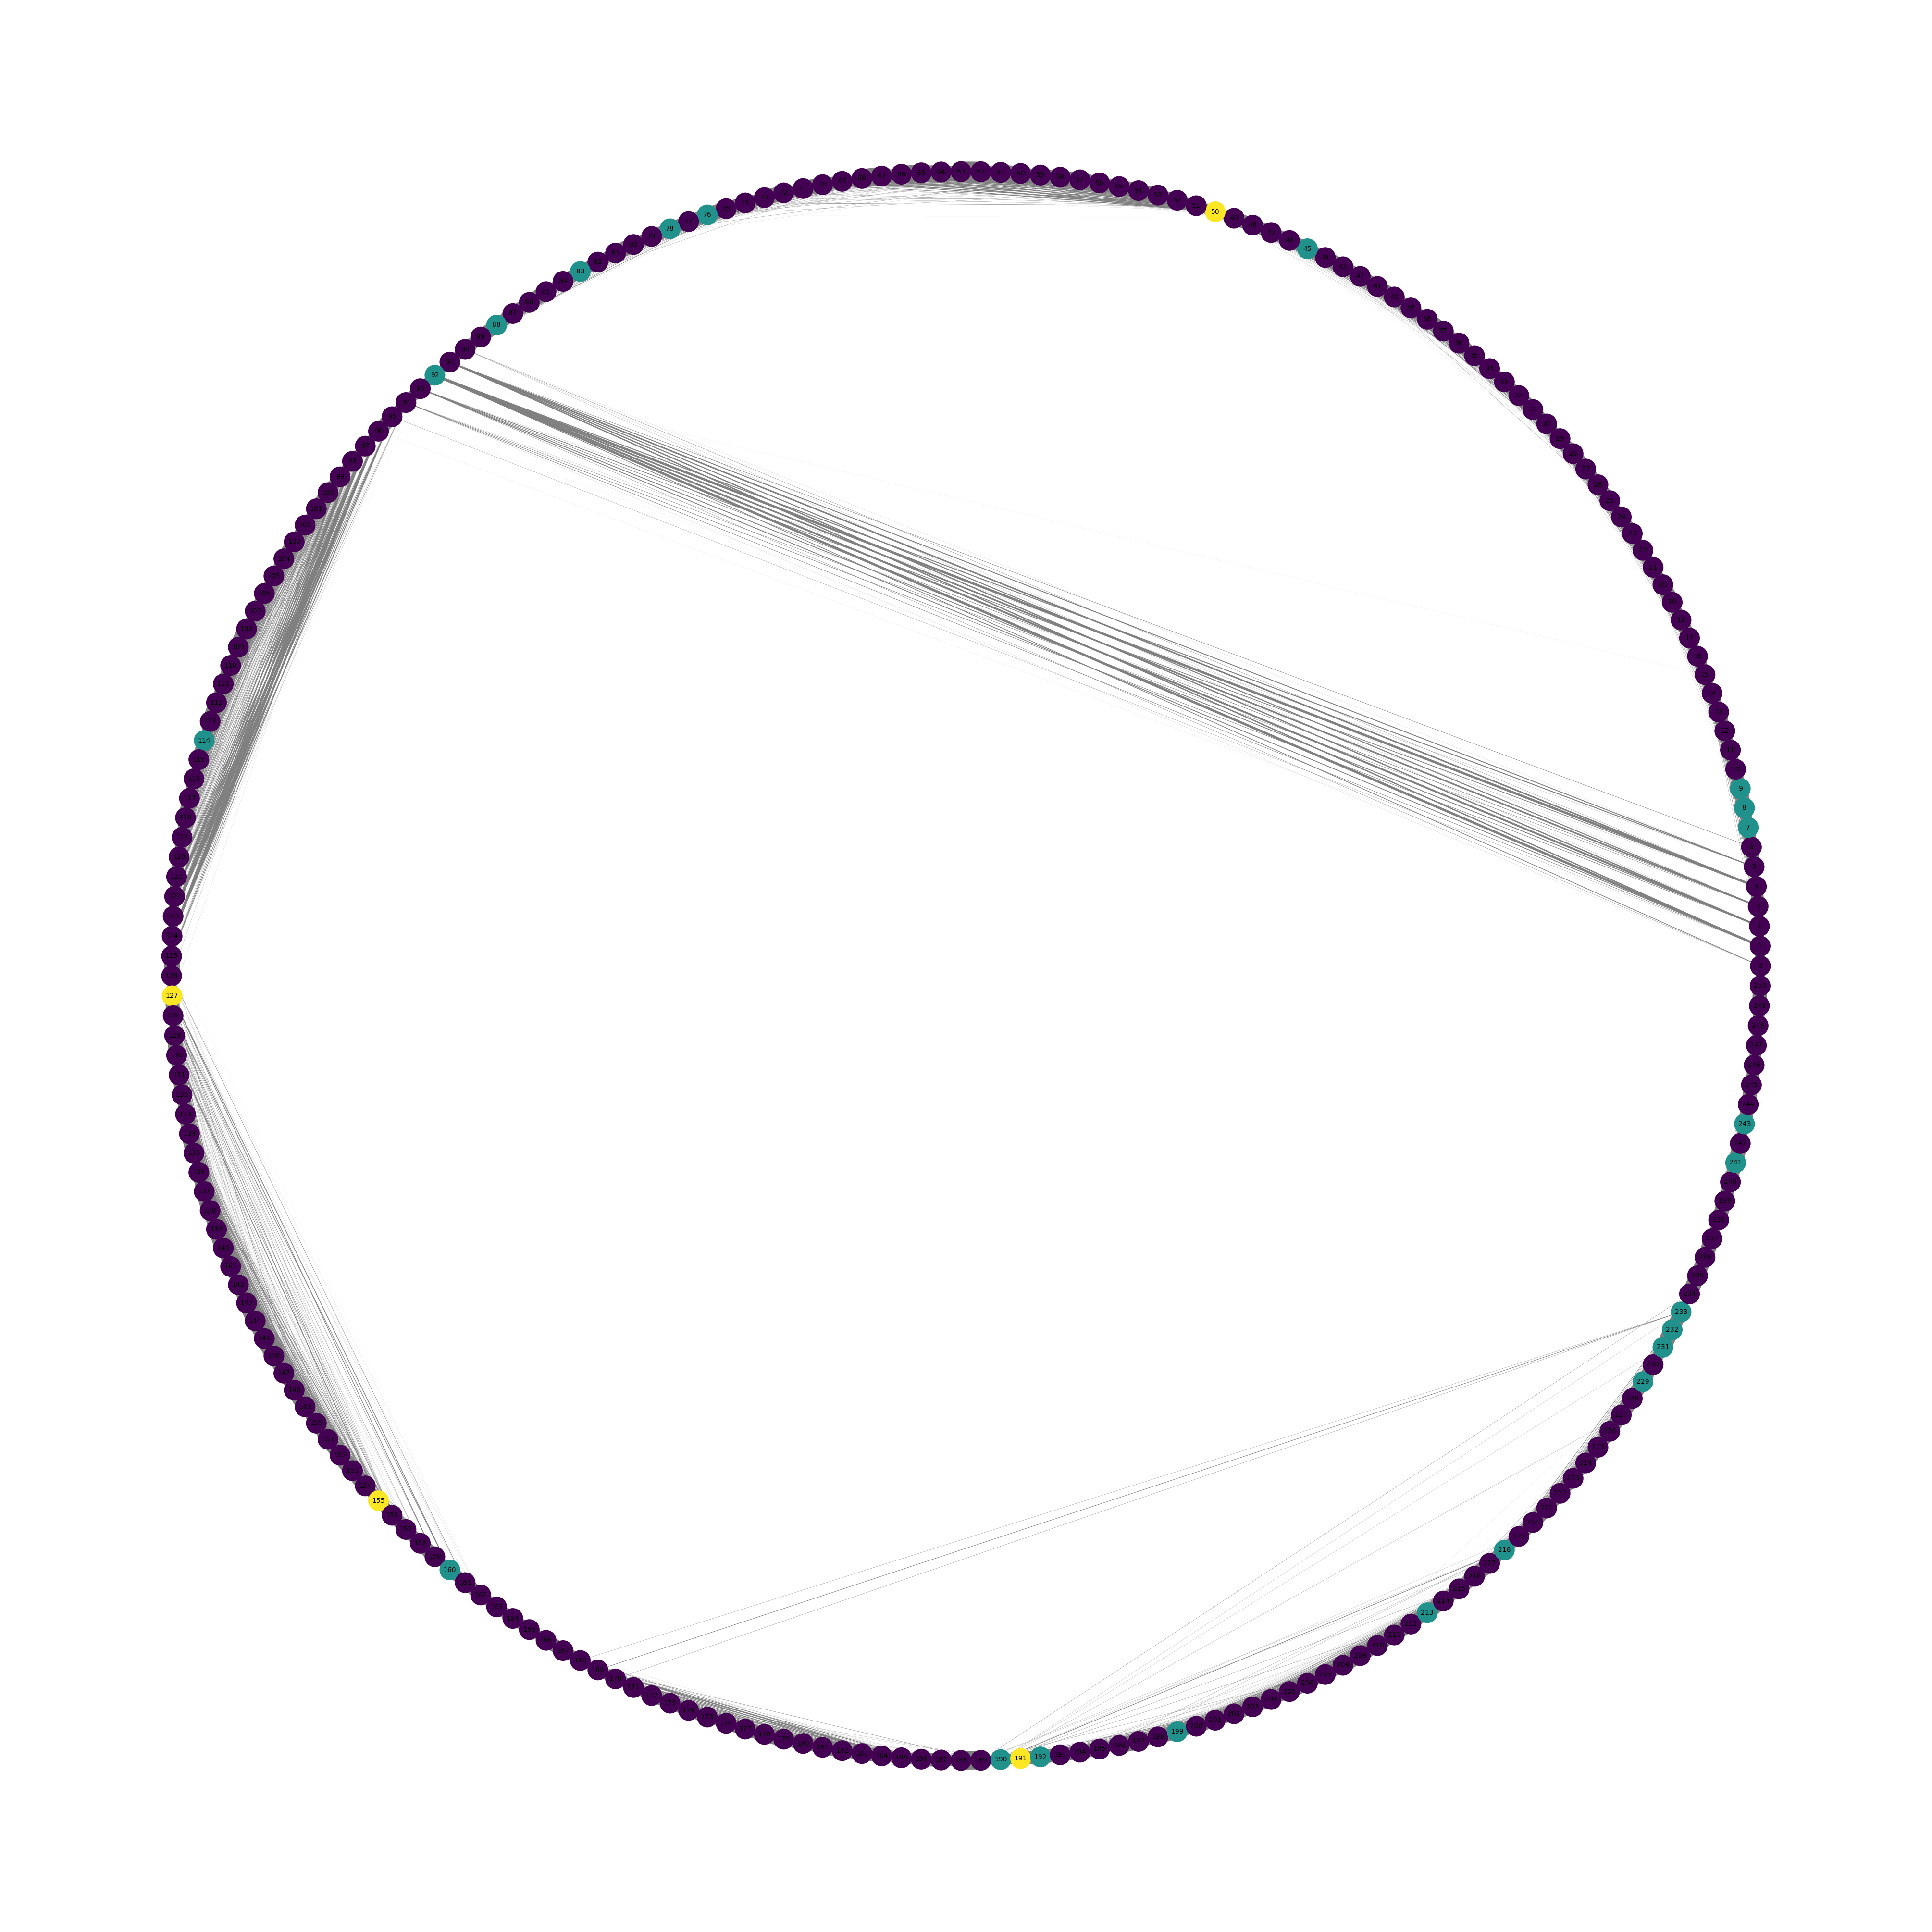

In [15]:
#pos = nx.kamada_kawai_layout(G)
pos = nx.circular_layout(G)

plt.figure(figsize=(40, 40))
nx.draw(
    G,
    pos,
    with_labels=True,
    width=[normalized_weights.get(edge, 1) for edge in G.edges],
    node_color=tot_genes,
    edge_color="gray",
    node_size=900,
    font_size=10,
)
plt.savefig('test.png')
plt.show()

In [16]:
thres = np.percentile(ec_hic, to_filter)
vis_ec = ec_hic.copy()
vis_ec[vis_ec < thres] = 0
np.fill_diagonal(vis_ec, 0)

G = nx.from_numpy_array(vis_ec)

edge_weights = nx.get_edge_attributes(G, "weight")
tot_genes = hic_ec_chr7.total_genes.to_numpy()
num_reads = np.log(hic_ec_chr7.read_count.to_numpy() + 0.0000000001)

max_weight = max(edge_weights.values())
min_weight = min(edge_weights.values())
normalized_weights = {
    edge: (weight - min_weight) * 30 / (max_weight - min_weight)
    for edge, weight in edge_weights.items()
}

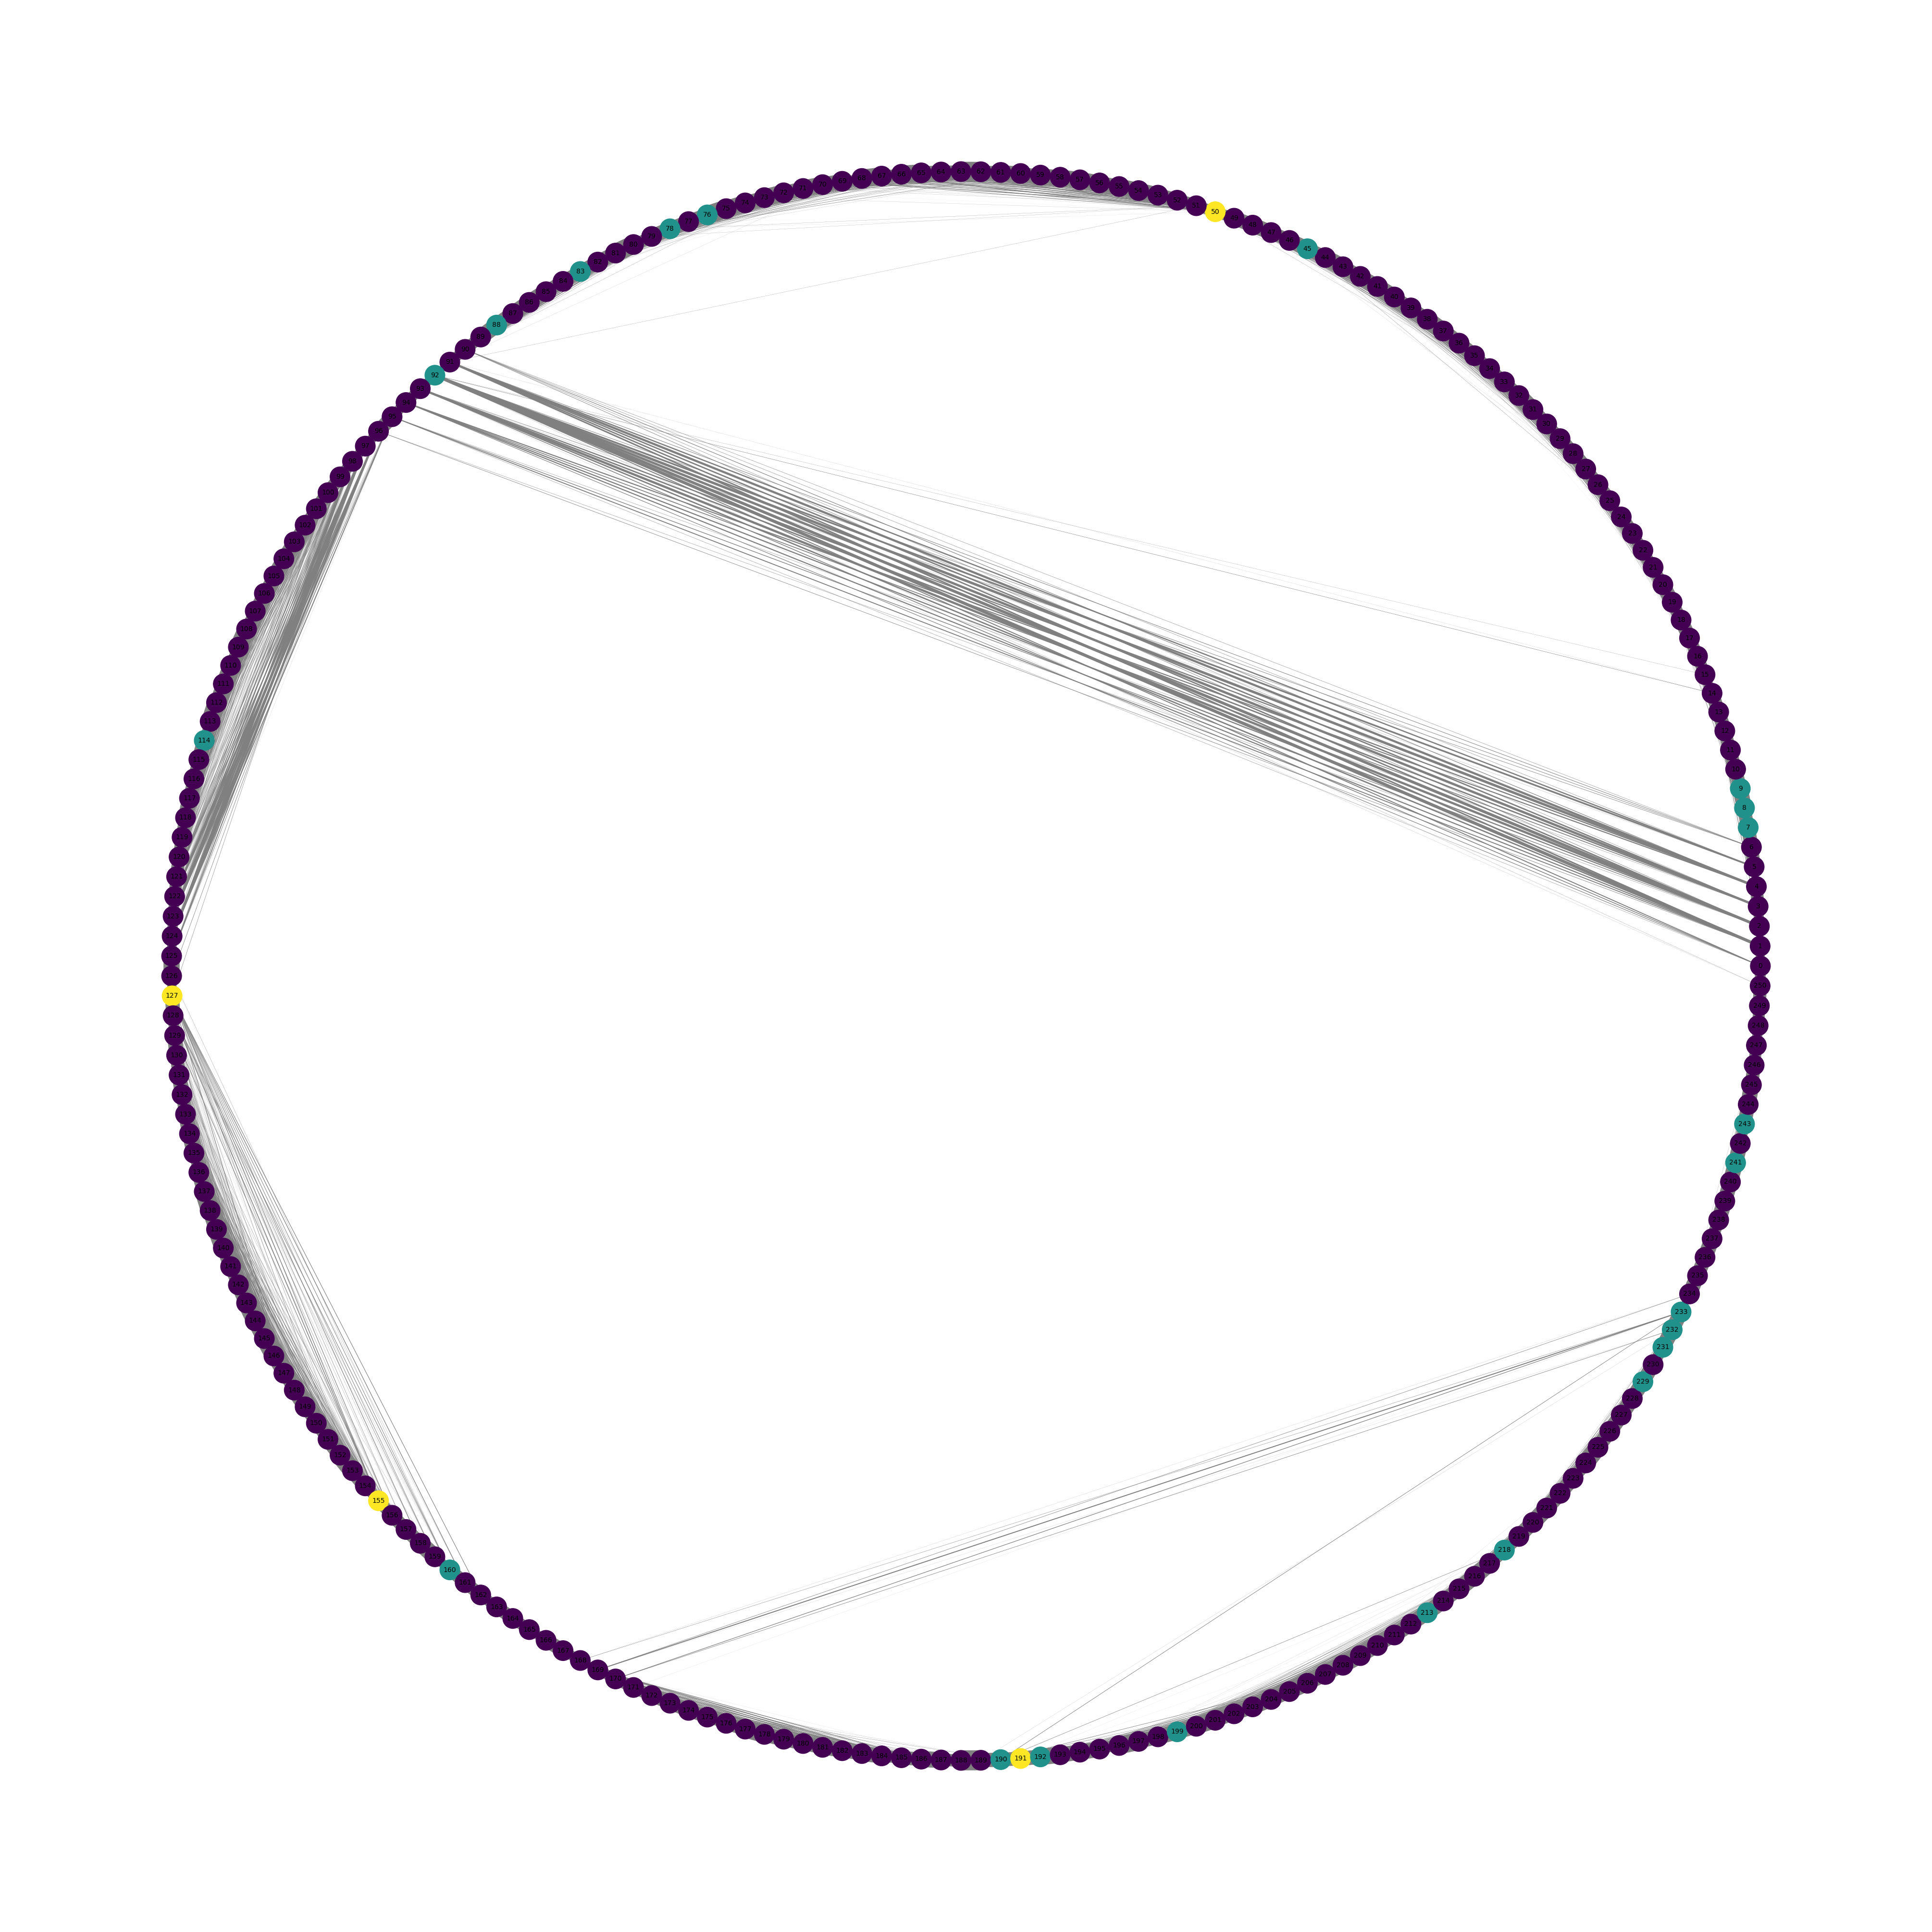

In [17]:
pos = nx.circular_layout(G)

plt.figure(figsize=(40, 40))
nx.draw(
    G,
    pos,
    with_labels=True,
    width=[normalized_weights.get(edge, 1) for edge in G.edges],
    node_color=tot_genes,
    edge_color="gray",
    node_size=900,
    font_size=10,
)
plt.show()

In [18]:
hsr_feats = torch.tensor(hic_hsr_chr7[['read_count', 'total_genes']].to_numpy())
hsr_labels = torch.zeros(hsr_feats.shape[0])
hsr_feats.shape

torch.Size([251, 2])

In [19]:
ec_feats = torch.tensor(hic_ec_chr7[['read_count', 'total_genes']].to_numpy())
ec_labels = torch.ones(ec_feats.shape[0])
ec_feats.shape

torch.Size([251, 2])

In [20]:
def hic_to_sparse(hic_mat):
    adj_mat = np.triu(hic_mat)
    sparse_adj = coo_matrix(adj_mat)

    return utils.from_scipy_sparse_matrix(sparse_adj)

hsr_edge_index, hsr_edge_attr = hic_to_sparse(hsr_hic)
hsr_graph = torch_geometric.data.Data(edge_index = hsr_edge_index, edge_attr = hsr_edge_attr, x = hsr_feats, y = hsr_labels)
hsr_graph

Data(x=[251, 2], edge_index=[2, 31625], edge_attr=[31625], y=[251])

In [21]:
ec_edge_index, ec_edge_attr = hic_to_sparse(ec_hic)
ec_graph = torch_geometric.data.Data(edge_index = ec_edge_index, edge_attr = ec_edge_attr, x = ec_feats, y = ec_labels)
ec_graph

Data(x=[251, 2], edge_index=[2, 31626], edge_attr=[31626], y=[251])

In [22]:
hic_hsr_chr7.total_genes.value_counts()

total_genes
0    225
1     22
2      4
Name: count, dtype: int64

In [23]:
5000 * 251 / 3000

418.3333333333333

In [24]:
hic_ec_chr7.to_csv('data/ec_cleaned.csv')
hic_hsr_chr7.to_csv('data/hsr_cleaned.csv')

In [29]:
hic_ec_chr7[hic_ec_chr7.total_genes != 0]

,chromosome,start,end,read_count,bases_covered,bin_size,coverage_fraction,total_genes,total_genes_length
257676,NC_000007.14,54800000,54805000,7,241,5000,0.0482,1,45656
257677,NC_000007.14,54805000,54810000,39,636,5000,0.1272,1,5690
257678,NC_000007.14,54810000,54815000,10,334,5000,0.0668,1,5690
257714,NC_000007.14,54990000,54995000,29,1427,5000,0.2854,1,26503
257719,NC_000007.14,55015000,55020000,185,2982,5000,0.5964,2,219114
257751,NC_000007.14,55175000,55180000,1021,5000,5000,1.0000,1,9199
257753,NC_000007.14,55185000,55190000,2133,5000,5000,1.0000,1,9199
257758,NC_000007.14,55210000,55215000,44676,5000,5000,1.0000,1,192611
257763,NC_000007.14,55235000,55240000,78,5000,5000,1.0000,1,17199
257767,NC_000007.14,55255000,55260000,819,5000,5000,1.0000,1,17199
